In [44]:
# use holodeck environment

In [45]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")

In [46]:
# copied from /home/sti50/neural_network/neural_network_instead_of_gp_error_plotting_similar_to_agazie_fig6.ipynb

In [47]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
plt.rcParams.update({"mathtext.fontset": "stix"}) # to have a font like latex files for all the plots
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os

# for SIDM

## GP accuracy

In [48]:
# copied from /home/users/sti50/neural_network/neural_network_instead_of_gp.ipynb

# load from npz file
npz_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n8000_r2000_f5/library2_gp_nn_accuracy/gp_predictions_for_8000_test_points.npz'
gp_prediction_test = np.load(npz_path_test)

gp_prediction_median_log10_hc2_test = gp_prediction_test['gp_prediction_median_log10_hc2']
gp_prediction_std_log10_hc2_test = gp_prediction_test['gp_prediction_std_log10_hc2']

# true values

# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n8000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    true_hc_test = f['gwb'][:]

# TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
##############################################
epsilon = 1e-20 # to avoid log(0)
true_log10_hc_test = np.log10(true_hc_test + epsilon)
true_log10_hc2_test = 2 * true_log10_hc_test
true_median_log10_hc2_test = np.median(true_log10_hc2_test, axis=-1)
true_std_log10_hc2_test = np.std(true_log10_hc2_test, axis=-1)
    
error_median_test = gp_prediction_median_log10_hc2_test - true_median_log10_hc2_test
error_std_test = gp_prediction_std_log10_hc2_test - true_std_log10_hc2_test


# Prepare data
x_median = error_median_test
y_median = true_median_log10_hc2_test
# x_median = error_median[mask]
# y_median = true_median_log10_hc2[mask]
x_median = x_median.ravel()
y_median = y_median.ravel()

# Kernel density estimate
xy_median = np.vstack([x_median, y_median])
kde_median = gaussian_kde(xy_median)
z_median = kde_median(xy_median)

# Sort the points by density (for plotting)
idx_median = z_median.argsort()
x_median, y_median, z_median = x_median[idx_median], y_median[idx_median], z_median[idx_median]


## for std
# Prepare data
x_std = error_std_test
y_std = true_std_log10_hc2_test
# x_std = error_std[mask]
# y_std = true_std_log10_hc2_data[mask]
x_std = x_std.ravel()
y_std = y_std.ravel()

# Kernel density estimate
xy_std = np.vstack([x_std, y_std])
kde_std = gaussian_kde(xy_std)
z_std = kde_std(xy_std)

# Sort the points by density (for plotting)
idx_std = z_std.argsort()
x_std, y_std, z_std = x_std[idx_std], y_std[idx_std], z_std[idx_std]

# Make contour levels for 20%, 50%, 90%
def density_contours(kde, x, y, levels=[0.2, 0.5, 0.9], gridsize=100):
    # Grid over the data range
    xgrid = np.linspace(x.min(), x.max(), gridsize)
    ygrid = np.linspace(y.min(), y.max(), gridsize)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Normalize density to cumulative probability
    Zflat = Z.flatten()
    Zsort = np.sort(Zflat)
    cdf = np.cumsum(Zsort)
    cdf /= cdf[-1]
    
    # Find density thresholds for given levels
    thresholds = [Zsort[np.searchsorted(cdf, lev)] for lev in levels]
    return X, Y, Z, thresholds

# gp_X_median_test_sidm, gp_Y_median_test_sidm, gp_Z_median_test_sidm, gp_thresholds_median_test_sidm = density_contours(kde_median, x_median, y_median)
gp_X_std_test_sidm, gp_Y_std_test_sidm, gp_Z_std_test_sidm, gp_thresholds_std_test_sidm = density_contours(kde_std, x_std, y_std)


## NN accuracy

In [49]:
nn_dir = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n8000_r2000_f5/nn_training_output'

from tensorflow import keras
import os
import tensorflow_probability as tfp
tfpl = tfp.layers
tfd = tfp.distributions
model_median = keras.models.load_model(
    os.path.join(nn_dir, "nn_model_median.keras"),
    custom_objects={"DistributionLambda": tfpl.DistributionLambda},
    compile=False,
    safe_mode=False
)

model_std = keras.models.load_model(
    os.path.join(nn_dir, "nn_model_std.keras"),
    custom_objects={"DistributionLambda": tfpl.DistributionLambda},
    compile=False,
    safe_mode=False
)


normalization_params = np.load(os.path.join(nn_dir, "normalization_params.npz"))
mu_x = normalization_params["mu_x"]
std_x = normalization_params["std_x"]
mu_y_median = normalization_params["mu_y_median"]
std_y_median = normalization_params["std_y_median"]
std_y_std = normalization_params["std_y_std"]
# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n8000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

# to figure out what keys are in the hdf5 file, comment in the print statement
with h5py.File(hdf5_file_path_test, 'r') as f:
    # print(f.keys())
    params_test = f['sample_params'][:]
unnormalized_test_param = params_test # shape (n, 6)
normalized_test_param = (unnormalized_test_param - mu_x) / std_x
y_pred_dist_median = model_median(normalized_test_param)
y_pred_median_nn = y_pred_dist_median.mean()
y_pred_median_unc_nn = y_pred_dist_median.stddev()
y_pred_dist_std = model_std(normalized_test_param)
y_pred_std_nn = y_pred_dist_std.mean()
y_pred_std_unc_nn = y_pred_dist_std.stddev()
y_pred_total_std_nn = np.sqrt(y_pred_median_unc_nn**2 + y_pred_std_nn**2 + y_pred_std_unc_nn**2)
y_pred_total_original_std_nn = y_pred_total_std_nn * std_y_std
y_pred_original_median_nn = y_pred_median_nn * std_y_median + mu_y_median
y_pred_original_median_nn = y_pred_original_median_nn.numpy()
# copied from /home/users/sti50/neural_network/neural_network_instead_of_gp.ipynb

nn_prediction_median_log10_hc2_test = y_pred_original_median_nn
nn_prediction_std_log10_hc2_test = y_pred_total_original_std_nn

# true values

# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n8000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    true_hc_test = f['gwb'][:]

# TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
##############################################
epsilon = 1e-20 # to avoid log(0)
true_log10_hc_test = np.log10(true_hc_test + epsilon)
true_log10_hc2_test = 2 * true_log10_hc_test
true_median_log10_hc2_test = np.median(true_log10_hc2_test, axis=-1)
true_std_log10_hc2_test = np.std(true_log10_hc2_test, axis=-1)
    
nn_error_median_test = nn_prediction_median_log10_hc2_test - true_median_log10_hc2_test
nn_error_std_test = nn_prediction_std_log10_hc2_test - true_std_log10_hc2_test


# Prepare data
x_median = nn_error_median_test
y_median = true_median_log10_hc2_test
# x_median = error_median[mask]
# y_median = true_median_log10_hc2[mask]
x_median = x_median.ravel()
y_median = y_median.ravel()

# Kernel density estimate
xy_median = np.vstack([x_median, y_median])
kde_median = gaussian_kde(xy_median)
z_median = kde_median(xy_median)

# Sort the points by density (for plotting)
idx_median = z_median.argsort()
x_median, y_median, z_median = x_median[idx_median], y_median[idx_median], z_median[idx_median]

## for std
# Prepare data
x_std = nn_error_std_test
y_std = true_std_log10_hc2_test
# x_std = error_std[mask]
# y_std = true_std_log10_hc2_data[mask]
x_std = x_std.ravel()
y_std = y_std.ravel()

# Kernel density estimate
xy_std = np.vstack([x_std, y_std])
kde_std = gaussian_kde(xy_std)
z_std = kde_std(xy_std)

# Sort the points by density (for plotting)
idx_std = z_std.argsort()
x_std, y_std, z_std = x_std[idx_std], y_std[idx_std], z_std[idx_std]

# Make contour levels for 20%, 50%, 90%
def density_contours(kde, x, y, levels=[0.2, 0.5, 0.9], gridsize=100):
    # Grid over the data range
    xgrid = np.linspace(x.min(), x.max(), gridsize)
    ygrid = np.linspace(y.min(), y.max(), gridsize)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Normalize density to cumulative probability
    Zflat = Z.flatten()
    Zsort = np.sort(Zflat)
    cdf = np.cumsum(Zsort)
    cdf /= cdf[-1]
    
    # Find density thresholds for given levels
    thresholds = [Zsort[np.searchsorted(cdf, lev)] for lev in levels]
    return X, Y, Z, thresholds

nn_X_median_test_sidm, nn_Y_median_test_sidm, nn_Z_median_test_sidm, nn_thresholds_median_test_sidm = density_contours(kde_median, x_median, y_median)
nn_X_std_test_sidm, nn_Y_std_test_sidm, nn_Z_std_test_sidm, nn_thresholds_std_test_sidm = density_contours(kde_std, x_std, y_std)


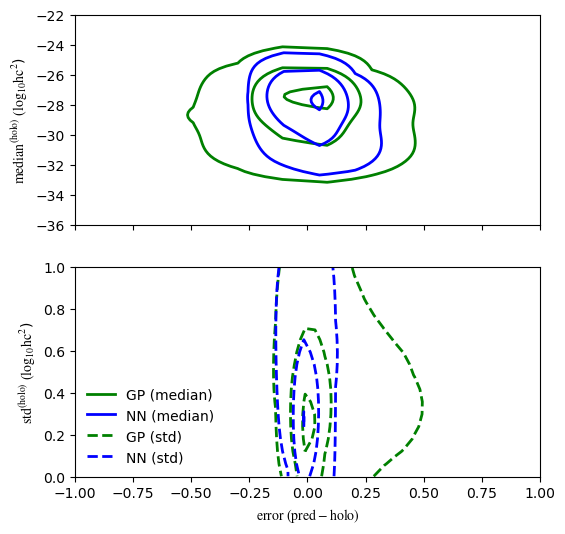

In [50]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=[6, 6])

xlim_lower = -1
xlim_upper = 1

# axes[0].scatter(x_median_test, y_median_test, s=0.5, alpha=0.1, color='green', label="points")
cs = axes[0].contour(gp_X_median_test_sidm, gp_Y_median_test_sidm, gp_Z_median_test_sidm, levels=gp_thresholds_median_test_sidm, colors='green', linewidths=2)
cs = axes[0].contour(nn_X_median_test_sidm, nn_Y_median_test_sidm, nn_Z_median_test_sidm, levels=nn_thresholds_median_test_sidm, colors='blue', linewidths=2)

# axes[0].set_xlabel("error")
axes[0].set_ylabel(r"$\mathrm{median^{(holo)}}\ (\mathrm{log_{10} hc^2}$)")
axes[0].set_xlim([xlim_lower, xlim_upper])
axes[0].tick_params(labelbottom=False)
axes[0].set_ylim([-36, -22])

# axes[1].scatter(x_std_test, y_std_test, s=0.5, alpha=0.1, color='green', label="points")
cs = axes[1].contour(gp_X_std_test_sidm, gp_Y_std_test_sidm, gp_Z_std_test_sidm, levels=gp_thresholds_std_test_sidm, colors='green', linewidths=2, linestyles='--')
cs = axes[1].contour(nn_X_std_test_sidm, nn_Y_std_test_sidm, nn_Z_std_test_sidm, levels=nn_thresholds_std_test_sidm, colors='blue', linewidths=2, linestyles='--')

# axes[1].set_xlabel("error")
axes[1].set_ylabel(r"$\mathrm{std^{(holo)}}\ (\mathrm{log_{10} hc^2}$)")
axes[1].set_xlim([xlim_lower, xlim_upper])
axes[1].set_ylim([0, 1])
axes[1].set_xlabel(r"$\mathrm{error \ (pred-holo)}$")

# for legends
legend_elements = [
    Line2D([0], [0], color='green', lw=2, ls='-',  label='GP (median)'),
    Line2D([0], [0], color='blue',  lw=2, ls='-',  label='NN (median)'),
    Line2D([0], [0], color='green', lw=2, ls='--', label='GP (std)'),
    Line2D([0], [0], color='blue',  lw=2, ls='--', label='NN (std)')
]
axes[1].legend(handles=legend_elements, loc='lower left', frameon=False)

fig.show()

# for phenom

In [51]:
# copied from /home/users/sti50/neural_network/neural_network_instead_of_gp.ipynb

# load from npz file
npz_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/library2_gp_nn_accuracy/gp_predictions_for_2000_test_points.npz'
gp_prediction_test = np.load(npz_path_test)

gp_prediction_median_log10_hc2_test = gp_prediction_test['gp_prediction_median_log10_hc2']
gp_prediction_std_log10_hc2_test = gp_prediction_test['gp_prediction_std_log10_hc2']

# true values

# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    true_hc_test = f['gwb'][:]

# TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
##############################################
epsilon = 1e-20 # to avoid log(0)
true_log10_hc_test = np.log10(true_hc_test + epsilon)
true_log10_hc2_test = 2 * true_log10_hc_test
true_median_log10_hc2_test = np.median(true_log10_hc2_test, axis=-1)
true_std_log10_hc2_test = np.std(true_log10_hc2_test, axis=-1)
    
error_median_test = gp_prediction_median_log10_hc2_test - true_median_log10_hc2_test
error_std_test = gp_prediction_std_log10_hc2_test - true_std_log10_hc2_test


# Prepare data
x_median = error_median_test
y_median = true_median_log10_hc2_test
# x_median = error_median[mask]
# y_median = true_median_log10_hc2[mask]
x_median = x_median.ravel()
y_median = y_median.ravel()

# Kernel density estimate
xy_median = np.vstack([x_median, y_median])
kde_median = gaussian_kde(xy_median)
z_median = kde_median(xy_median)

# Sort the points by density (for plotting)
idx_median = z_median.argsort()
x_median, y_median, z_median = x_median[idx_median], y_median[idx_median], z_median[idx_median]

## for std
# Prepare data
x_std = error_std_test
y_std = true_std_log10_hc2_test
# x_std = error_std[mask]
# y_std = true_std_log10_hc2_data[mask]
x_std = x_std.ravel()
y_std = y_std.ravel()

# Kernel density estimate
xy_std = np.vstack([x_std, y_std])
kde_std = gaussian_kde(xy_std)
z_std = kde_std(xy_std)

# Sort the points by density (for plotting)
idx_std = z_std.argsort()
x_std, y_std, z_std = x_std[idx_std], y_std[idx_std], z_std[idx_std]

# Make contour levels for 20%, 50%, 90%
def density_contours(kde, x, y, levels=[0.2, 0.5, 0.9], gridsize=100):
    # Grid over the data range
    xgrid = np.linspace(x.min(), x.max(), gridsize)
    ygrid = np.linspace(y.min(), y.max(), gridsize)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Normalize density to cumulative probability
    Zflat = Z.flatten()
    Zsort = np.sort(Zflat)
    cdf = np.cumsum(Zsort)
    cdf /= cdf[-1]
    
    # Find density thresholds for given levels
    thresholds = [Zsort[np.searchsorted(cdf, lev)] for lev in levels]
    return X, Y, Z, thresholds

X_median_test, Y_median_test, Z_median_test, thresholds_median_test = density_contours(kde_median, x_median, y_median)
X_std_test, Y_std_test, Z_std_test, thresholds_std_test = density_contours(kde_std, x_std, y_std)

# for error pdf plot (only for test set)
errors_median = error_median_test.ravel()
# Fit a normal distribution
mu_median, sigma_median = norm.fit(errors_median)
# Normal PDF for plotting
xvals_median = np.linspace(errors_median.min(), errors_median.max(), 500)
pdf_median = norm.pdf(xvals_median, mu_median, sigma_median)
# Add quantile lines
q50_median = np.percentile(errors_median, [25, 75])   # 50% central interval
q90_median = np.percentile(errors_median, [5, 95])    # 90% central interval

## for std
errors_std = error_std_test.ravel()
# Fit a normal distribution
mu_std, sigma_std = norm.fit(errors_std)
# Normal PDF for plotting
xvals_std = np.linspace(errors_std.min(), errors_std.max(), 500)
pdf_std = norm.pdf(xvals_std, mu_std, sigma_std)
# Add quantile lines
q50_std = np.percentile(errors_std, [25, 75])   # 50% central interval
q90_std = np.percentile(errors_std, [5, 95])    # 90% central interval


In [52]:
nn_dir = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/nn_training_output'

from tensorflow import keras
import os
import tensorflow_probability as tfp
tfpl = tfp.layers
tfd = tfp.distributions
model_median = keras.models.load_model(
    os.path.join(nn_dir, "nn_model_median.keras"),
    custom_objects={"DistributionLambda": tfpl.DistributionLambda},
    compile=False,
    safe_mode=False
)

model_std = keras.models.load_model(
    os.path.join(nn_dir, "nn_model_std.keras"),
    custom_objects={"DistributionLambda": tfpl.DistributionLambda},
    compile=False,
    safe_mode=False
)


normalization_params = np.load(os.path.join(nn_dir, "normalization_params.npz"))
mu_x = normalization_params["mu_x"]
std_x = normalization_params["std_x"]
mu_y_median = normalization_params["mu_y_median"]
std_y_median = normalization_params["std_y_median"]
std_y_std = normalization_params["std_y_std"]
# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

# to figure out what keys are in the hdf5 file, comment in the print statement
with h5py.File(hdf5_file_path_test, 'r') as f:
    # print(f.keys())
    params_test = f['sample_params'][:]
unnormalized_test_param = params_test # shape (n, 6)
normalized_test_param = (unnormalized_test_param - mu_x) / std_x
y_pred_dist_median = model_median(normalized_test_param)
y_pred_median_nn = y_pred_dist_median.mean()
y_pred_median_unc_nn = y_pred_dist_median.stddev()
y_pred_dist_std = model_std(normalized_test_param)
y_pred_std_nn = y_pred_dist_std.mean()
y_pred_std_unc_nn = y_pred_dist_std.stddev()
y_pred_total_std_nn = np.sqrt(y_pred_median_unc_nn**2 + y_pred_std_nn**2 + y_pred_std_unc_nn**2)
y_pred_total_original_std_nn = y_pred_total_std_nn * std_y_std
y_pred_original_median_nn = y_pred_median_nn * std_y_median + mu_y_median
y_pred_original_median_nn = y_pred_original_median_nn.numpy()
# copied from /home/users/sti50/neural_network/neural_network_instead_of_gp.ipynb

nn_prediction_median_log10_hc2_test = y_pred_original_median_nn
nn_prediction_std_log10_hc2_test = y_pred_total_original_std_nn

# true values

# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    true_hc_test = f['gwb'][:]

# TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
##############################################
epsilon = 1e-20 # to avoid log(0)
true_log10_hc_test = np.log10(true_hc_test + epsilon)
true_log10_hc2_test = 2 * true_log10_hc_test
true_median_log10_hc2_test = np.median(true_log10_hc2_test, axis=-1)
true_std_log10_hc2_test = np.std(true_log10_hc2_test, axis=-1)
    
nn_error_median_test = nn_prediction_median_log10_hc2_test - true_median_log10_hc2_test
nn_error_std_test = nn_prediction_std_log10_hc2_test - true_std_log10_hc2_test


# Prepare data
x_median = nn_error_median_test
y_median = true_median_log10_hc2_test
# x_median = error_median[mask]
# y_median = true_median_log10_hc2[mask]
x_median = x_median.ravel()
y_median = y_median.ravel()

# Kernel density estimate
xy_median = np.vstack([x_median, y_median])
kde_median = gaussian_kde(xy_median)
z_median = kde_median(xy_median)

# Sort the points by density (for plotting)
idx_median = z_median.argsort()
x_median, y_median, z_median = x_median[idx_median], y_median[idx_median], z_median[idx_median]

## for std
# Prepare data
x_std = nn_error_std_test
y_std = true_std_log10_hc2_test
# x_std = error_std[mask]
# y_std = true_std_log10_hc2_data[mask]
x_std = x_std.ravel()
y_std = y_std.ravel()

# Kernel density estimate
xy_std = np.vstack([x_std, y_std])
kde_std = gaussian_kde(xy_std)
z_std = kde_std(xy_std)

# Sort the points by density (for plotting)
idx_std = z_std.argsort()
x_std, y_std, z_std = x_std[idx_std], y_std[idx_std], z_std[idx_std]

# Make contour levels for 20%, 50%, 90%
def density_contours(kde, x, y, levels=[0.2, 0.5, 0.9], gridsize=100):
    # Grid over the data range
    xgrid = np.linspace(x.min(), x.max(), gridsize)
    ygrid = np.linspace(y.min(), y.max(), gridsize)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Normalize density to cumulative probability
    Zflat = Z.flatten()
    Zsort = np.sort(Zflat)
    cdf = np.cumsum(Zsort)
    cdf /= cdf[-1]
    
    # Find density thresholds for given levels
    thresholds = [Zsort[np.searchsorted(cdf, lev)] for lev in levels]
    return X, Y, Z, thresholds

nn_X_median_test, nn_Y_median_test, nn_Z_median_test, nn_thresholds_median_test = density_contours(kde_median, x_median, y_median)
nn_X_std_test, nn_Y_std_test, nn_Z_std_test, nn_thresholds_std_test = density_contours(kde_std, x_std, y_std)

# for error pdf plot (only for test set)
errors_median = nn_error_median_test.ravel()
# Fit a normal distribution
mu_median, sigma_median = norm.fit(errors_median)
# Normal PDF for plotting
nn_xvals_median = np.linspace(errors_median.min(), errors_median.max(), 500)
nn_pdf_median = norm.pdf(nn_xvals_median, mu_median, sigma_median)
# Add quantile lines
nn_q50_median = np.percentile(errors_median, [25, 75])   # 50% central interval
nn_q90_median = np.percentile(errors_median, [5, 95])    # 90% central interval

## for std
errors_std = nn_error_std_test.ravel()
# Fit a normal distribution
mu_std, sigma_std = norm.fit(errors_std)
# Normal PDF for plotting
nn_xvals_std = np.linspace(errors_std.min(), errors_std.max(), 500)
nn_pdf_std = norm.pdf(nn_xvals_std, mu_std, sigma_std)
# Add quantile lines
nn_q50_std = np.percentile(errors_std, [25, 75])   # 50% central interval
nn_q90_std = np.percentile(errors_std, [5, 95])    # 90% central interval



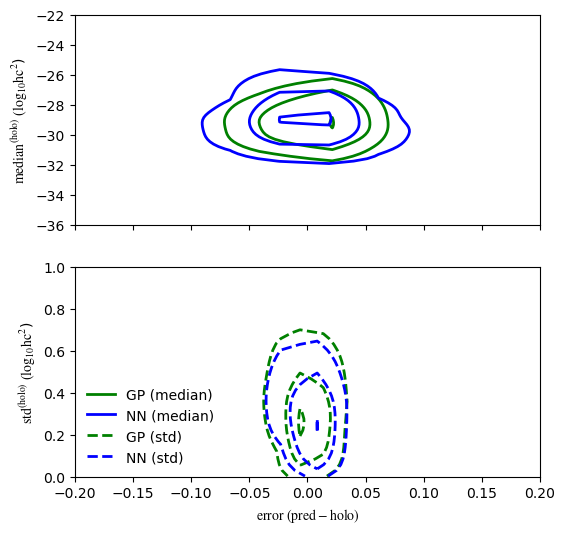

In [53]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=[6, 6])

lim = 0.2
xlim_lower = -lim
xlim_upper = lim

# axes[0].scatter(x_median_test, y_median_test, s=0.5, alpha=0.1, color='green', label="points")
cs = axes[0].contour(X_median_test, Y_median_test, Z_median_test, levels=thresholds_median_test, colors='green', linewidths=2)
cs = axes[0].contour(nn_X_median_test, nn_Y_median_test, nn_Z_median_test, levels=nn_thresholds_median_test, colors='blue', linewidths=2)

# axes[0].set_xlabel("error")
axes[0].set_ylabel(r"$\mathrm{median^{(holo)}}\ (\mathrm{log_{10} hc^2}$)")
axes[0].set_xlim([xlim_lower, xlim_upper])
axes[0].tick_params(labelbottom=False)
axes[0].set_ylim([-36, -22])

# axes[1].scatter(x_std_test, y_std_test, s=0.5, alpha=0.1, color='green', label="points")
cs = axes[1].contour(X_std_test, Y_std_test, Z_std_test, levels=thresholds_std_test, colors='green', linewidths=2, linestyles='--')
cs = axes[1].contour(nn_X_std_test, nn_Y_std_test, nn_Z_std_test, levels=nn_thresholds_std_test, colors='blue', linewidths=2, linestyles='--')

# axes[1].set_xlabel("error")
axes[1].set_ylabel(r"$\mathrm{std^{(holo)}}\ (\mathrm{log_{10} hc^2}$)")
axes[1].set_xlim([xlim_lower, xlim_upper])
axes[1].set_ylim([0, 1])
axes[1].set_xlabel(r"$\mathrm{error \ (pred - holo)}$")

# for legends
legend_elements = [
    Line2D([0], [0], color='green', lw=2, ls='-',  label='GP (median)'),
    Line2D([0], [0], color='blue',  lw=2, ls='-',  label='NN (median)'),
    Line2D([0], [0], color='green', lw=2, ls='--', label='GP (std)'),
    Line2D([0], [0], color='blue',  lw=2, ls='--', label='NN (std)')
]

axes[1].legend(handles=legend_elements, loc='lower left', frameon=False)

fig.show()